# HDB Dataset — Data Profiling & Cleaning

This notebook performs:
1. **Data Profiling:** understand structure, types, distributions, missing values, duplicates, and outliers
2. **Data Cleaning:** fix issues found during profiling
3. **Validation:** confirm the cleaned dataset is consistent and ready for downstream use

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_PATH = '../dataset/hdb.csv'
CLEAN_PATH = '../dataset/hdb_cleaned.csv'

---
## 1. Data Profiling

### 1.1 Load & Basic Info

In [32]:
df = pd.read_csv(DATA_PATH, index_col=0)
print(f'Shape: {df.shape}  ({df.shape[0]} rows × {df.shape[1]} columns)')
df.head()

Shape: (12442, 36)  (12442 rows × 36 columns)


,blk_no,street,max_floor_lvl,year_completed,residential,commercial,market_hawker,miscellaneous,multistorey_carpark,precinct_pavilion,bldg_contract_town,total_dwelling_units,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,multigen_sold,studio_apartment_sold,1room_rental,2room_rental,3room_rental,other_room_rental,lat,lng,building,addr,postal,SUBZONE_NO,SUBZONE_N,SUBZONE_C,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C
0,1,BEACH RD,16,1970,Y,Y,N,N,N,N,KWN,142,0,1,138,1,2,0,0,0,0,0,0,0,1.2951,103.8541,RAFFLES HOTEL,1 BEACH ROAD RAFFLES HOTEL SINGAPORE 189673,189673,2.0000,CITY HALL,DTSZ02,DOWNTOWN CORE,DT,CENTRAL REGION,CR
1,1,BEDOK STH AVE 1,14,1975,Y,N,N,Y,N,N,BD,206,0,0,204,0,2,0,0,0,0,0,0,0,1.3209,103.9337,NIL,1 BEDOK SOUTH AVENUE 1 SINGAPORE 460001,460001,6.0000,BEDOK SOUTH,BDSZ06,BEDOK,BD,EAST REGION,ER
2,1,CANTONMENT RD,2,2010,N,Y,N,N,N,N,CT,0,0,0,0,0,0,0,0,0,0,0,0,0,1.2755,103.8414,PINNACLE @ DUXTON,1 CANTONMENT ROAD PINNACLE @ DUXTON SINGAPORE ...,080001,3.0000,CHINATOWN,OTSZ03,OUTRAM,OT,CENTRAL REGION,CR
3,1,CHAI CHEE RD,15,1982,Y,N,N,N,N,N,BD,102,0,0,0,10,92,0,0,0,0,0,0,0,1.3280,103.9227,PING YI GARDENS,1 CHAI CHEE ROAD PING YI GARDENS SINGAPORE 461001,461001,3.0000,KEMBANGAN,BDSZ03,BEDOK,BD,EAST REGION,ER
4,1,CHANGI VILLAGE RD,4,1975,Y,Y,N,N,N,N,PRC,55,0,0,54,0,1,0,0,0,0,0,0,0,1.3886,103.9881,OCBC CHANGI VILLAGE ROAD - 7 ELEVEN,1 CHANGI VILLAGE ROAD OCBC CHANGI VILLAGE ROAD...,500001,1.0000,CHANGI POINT,CHSZ01,CHANGI,CH,EAST REGION,ER


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12442 entries, 0 to 12441
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   blk_no                 12442 non-null  str    
 1   street                 12442 non-null  str    
 2   max_floor_lvl          12442 non-null  int64  
 3   year_completed         12442 non-null  int64  
 4   residential            12442 non-null  str    
 5   commercial             12442 non-null  str    
 6   market_hawker          12442 non-null  str    
 7   miscellaneous          12442 non-null  str    
 8   multistorey_carpark    12442 non-null  str    
 9   precinct_pavilion      12442 non-null  str    
 10  bldg_contract_town     12442 non-null  str    
 11  total_dwelling_units   12442 non-null  int64  
 12  1room_sold             12442 non-null  int64  
 13  2room_sold             12442 non-null  int64  
 14  3room_sold             12442 non-null  int64  
 15  4room_sold   

In [34]:
df.describe(include='all')

,blk_no,street,max_floor_lvl,year_completed,residential,commercial,market_hawker,miscellaneous,multistorey_carpark,precinct_pavilion,bldg_contract_town,total_dwelling_units,1room_sold,2room_sold,3room_sold,4room_sold,5room_sold,exec_sold,multigen_sold,studio_apartment_sold,1room_rental,2room_rental,3room_rental,other_room_rental,lat,lng,building,addr,postal,SUBZONE_NO,SUBZONE_N,SUBZONE_C,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C
count,12442,12442,12442.0000,12442.0000,12442,12442,12442,12442,12442,12442,12442,12442.0000,12442.0000,12442.0000,12442.0000,12442.0000,12442.0000,12442.0000,12442.0000,12442.0000,12442.0000,12442.0000,12442.0000,12442.0000,12442.0000,12442.0000,12442,12442,12442,12441.0000,12441,12441,12441,12441,12441,12441
unique,3239,629,NaN,NaN,2,2,2,2,2,2,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1797,12430,12354,NaN,161,161,31,31,5,5
top,1,YISHUN RING RD,NaN,NaN,Y,N,N,N,N,N,TAP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NIL,118C JALAN MEMBINA MEMBINA 118 SINGAPORE 163118,NIL,NaN,TAMPINES EAST,TMSZ02,TAMPINES,TM,WEST REGION,WR
freq,34,158,NaN,NaN,10181,9934,12330,9619,11412,11679,937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5045,2,76,NaN,498,498,937,937,2961,2961
mean,NaN,NaN,12.0321,1993.5514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,87.6655,0.0205,2.4151,19.6560,34.6568,19.8487,5.2040,0.0295,0.7066,2.4761,2.5042,0.1372,0.0098,1.3654,103.8410,NaN,NaN,NaN,4.2180,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,7.0386,13.9817,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65.7437,2.2861,14.1187,45.0948,40.6891,29.8550,17.4474,1.2330,7.8270,24.5891,21.5554,2.7129,0.5137,0.0426,0.0731,NaN,NaN,NaN,2.5862,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.0000,1937.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.2704,103.6852,NaN,NaN,NaN,1.0000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,6.0000,1984.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.3364,103.7765,NaN,NaN,NaN,2.0000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,12.0000,1993.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90.0000,0.0000,0.0000,0.0000,22.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.3632,103.8461,NaN,NaN,NaN,4.0000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,16.0000,2001.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.0000,0.0000,0.0000,6.0000,58.0000,40.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.3926,103.8992,NaN,NaN,NaN,5.0000,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 Missing Values

7 columns with missing values:



,count,pct
SUBZONE_NO,1,0.0100
SUBZONE_N,1,0.0100
SUBZONE_C,1,0.0100
PLN_AREA_N,1,0.0100
PLN_AREA_C,1,0.0100
REGION_N,1,0.0100
REGION_C,1,0.0100


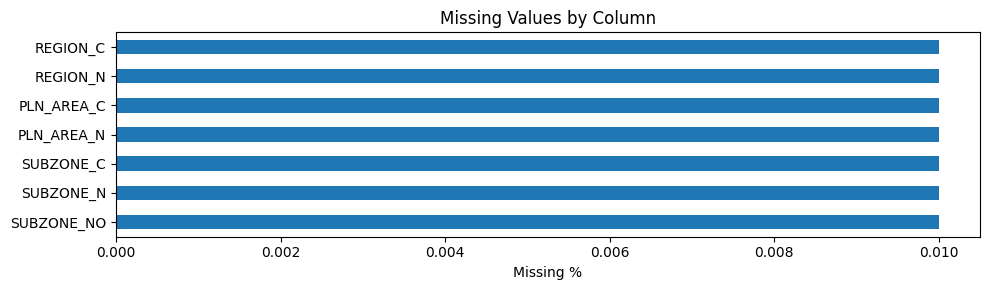

In [35]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_df = missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False)

if missing_df.empty:
    print('No missing values found.')
else:
    print(f'{len(missing_df)} columns with missing values:\n')
    display(missing_df)
    
    fig, ax = plt.subplots(figsize=(10, max(3, len(missing_df) * 0.4)))
    missing_df['pct'].plot.barh(ax=ax)
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column')
    plt.tight_layout()
    plt.show()

### 1.3 Duplicates

In [36]:
n_dup = df.duplicated().sum()
print(f'Fully duplicated rows: {n_dup}')

# Check near-duplicates by key columns (blk_no + street should be unique per building)
key_cols = ['blk_no', 'street']
n_key_dup = df.duplicated(subset=key_cols).sum()
print(f'Duplicate (blk_no, street) pairs: {n_key_dup}')

if n_key_dup > 0:
    dup_keys = df[df.duplicated(subset=key_cols, keep=False)].sort_values(key_cols)
    print(f'\nShowing first few duplicate groups:')
    display(dup_keys.head(10))

Fully duplicated rows: 0
Duplicate (blk_no, street) pairs: 0


### 1.4 Column-Type Audit

In [37]:
# Y/N flag columns — check for unexpected values
flag_cols = ['residential', 'commercial', 'market_hawker', 'miscellaneous',
             'multistorey_carpark', 'precinct_pavilion']

print('Unique values in Y/N flag columns:')
for col in flag_cols:
    vals = df[col].unique()
    unexpected = [v for v in vals if v not in ('Y', 'N', np.nan)]
    status = '⚠ UNEXPECTED' if unexpected else '✓'
    print(f'  {col}: {vals}  {status}')

Unique values in Y/N flag columns:
  residential: <StringArray>
['Y', 'N']
Length: 2, dtype: str  ✓
  commercial: <StringArray>
['Y', 'N']
Length: 2, dtype: str  ✓
  market_hawker: <StringArray>
['N', 'Y']
Length: 2, dtype: str  ✓
  miscellaneous: <StringArray>
['N', 'Y']
Length: 2, dtype: str  ✓
  multistorey_carpark: <StringArray>
['N', 'Y']
Length: 2, dtype: str  ✓
  precinct_pavilion: <StringArray>
['N', 'Y']
Length: 2, dtype: str  ✓


In [38]:
# Numeric columns — check for negative values or obvious outliers
numeric_cols = df.select_dtypes(include='number').columns.tolist()
print(f'Numeric columns ({len(numeric_cols)}): {numeric_cols}\n')

for col in numeric_cols:
    neg = (df[col] < 0).sum()
    if neg > 0:
        print(f'  ⚠ {col}: {neg} negative values')

# Expect non-negative counts for unit columns
unit_cols = ['total_dwelling_units', '1room_sold', '2room_sold', '3room_sold',
             '4room_sold', '5room_sold', 'exec_sold', 'multigen_sold',
             'studio_apartment_sold', '1room_rental', '2room_rental',
             '3room_rental', 'other_room_rental']
print('\nUnit count columns — min values:')
display(df[unit_cols].min().to_frame('min'))

Numeric columns (18): ['max_floor_lvl', 'year_completed', 'total_dwelling_units', '1room_sold', '2room_sold', '3room_sold', '4room_sold', '5room_sold', 'exec_sold', 'multigen_sold', 'studio_apartment_sold', '1room_rental', '2room_rental', '3room_rental', 'other_room_rental', 'lat', 'lng', 'SUBZONE_NO']


Unit count columns — min values:


,min
total_dwelling_units,0
1room_sold,0
2room_sold,0
3room_sold,0
4room_sold,0
5room_sold,0
exec_sold,0
multigen_sold,0
studio_apartment_sold,0
1room_rental,0


### 1.5 Distribution of Numeric Columns

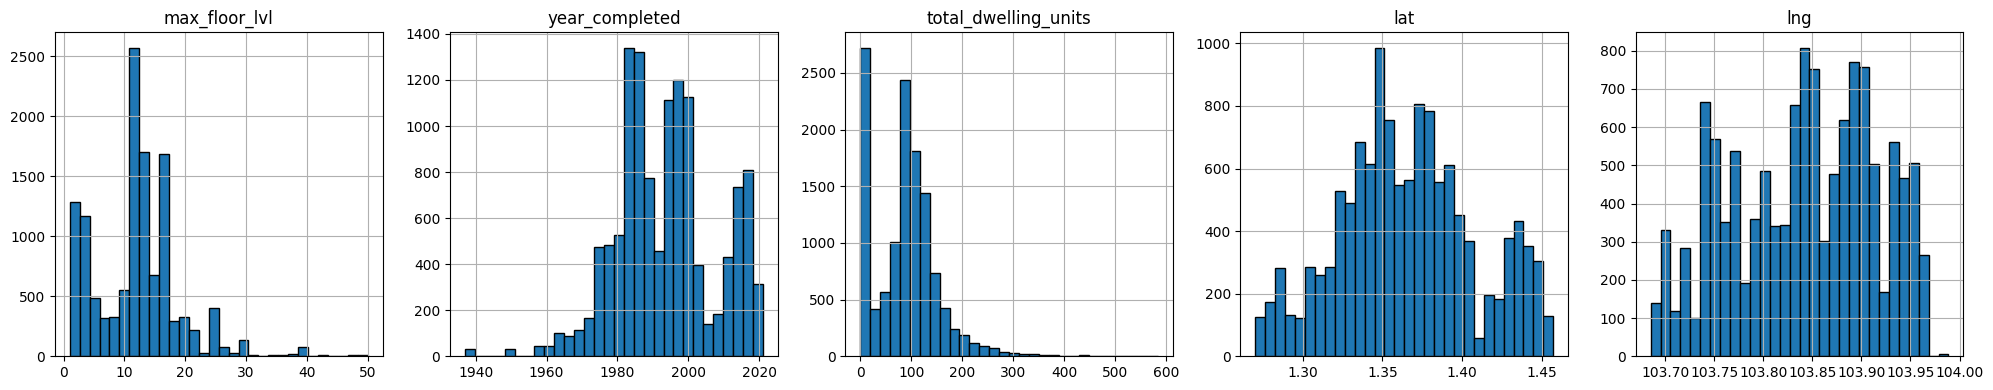

In [39]:
# Histograms for key numeric columns
plot_cols = ['max_floor_lvl', 'year_completed', 'total_dwelling_units', 'lat', 'lng']
fig, axes = plt.subplots(1, len(plot_cols), figsize=(4 * len(plot_cols), 4))
for ax, col in zip(axes, plot_cols):
    df[col].dropna().hist(bins=30, ax=ax, edgecolor='black')
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 1.6 Outlier Detection (IQR)

In [40]:
outlier_cols = ['max_floor_lvl', 'year_completed', 'total_dwelling_units', 'lat', 'lng']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col}: IQR=[{Q1:.2f}, {Q3:.2f}], bounds=[{lower:.2f}, {upper:.2f}], outliers={n_out}')

max_floor_lvl: IQR=[6.00, 16.00], bounds=[-9.00, 31.00], outliers=154
year_completed: IQR=[1984.00, 2001.00], bounds=[1958.50, 2026.50], outliers=68
total_dwelling_units: IQR=[34.00, 120.00], bounds=[-95.00, 249.00], outliers=247
lat: IQR=[1.34, 1.39], bounds=[1.25, 1.48], outliers=0
lng: IQR=[103.78, 103.90], bounds=[103.59, 104.08], outliers=0


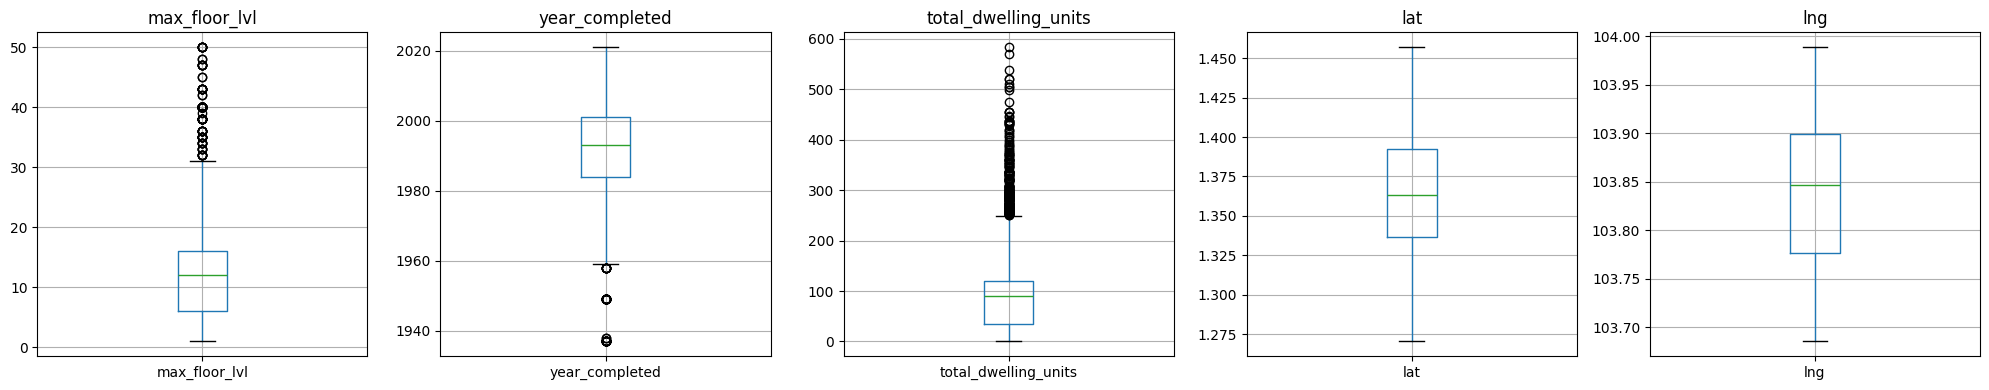

In [41]:
# Boxplots
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(4 * len(outlier_cols), 4))
for ax, col in zip(axes, outlier_cols):
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 1.7 Coordinate Sanity Check

In [42]:
# Singapore bounding box: lat ~1.15–1.47, lng ~103.6–104.1
SG_LAT = (1.15, 1.47)
SG_LNG = (103.6, 104.1)

out_of_bounds = df[
    (df['lat'] < SG_LAT[0]) | (df['lat'] > SG_LAT[1]) |
    (df['lng'] < SG_LNG[0]) | (df['lng'] > SG_LNG[1])
]
print(f'Coordinates outside Singapore bounding box: {len(out_of_bounds)}')
if len(out_of_bounds) > 0:
    display(out_of_bounds[['blk_no', 'street', 'lat', 'lng', 'addr']].head(10))

Coordinates outside Singapore bounding box: 0


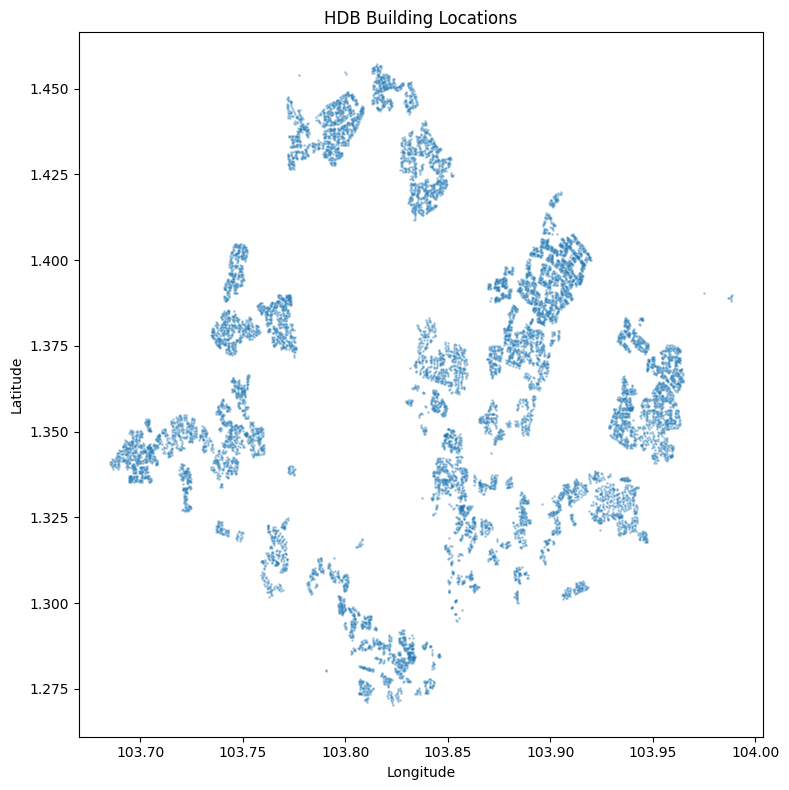

In [43]:
# Scatter plot of coordinates
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(df['lng'], df['lat'], s=1, alpha=0.3)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('HDB Building Locations')
plt.tight_layout()
plt.show()

### 1.8 Categorical Columns

In [44]:
cat_cols = ['bldg_contract_town', 'SUBZONE_N', 'PLN_AREA_N', 'REGION_N']

for col in cat_cols:
    print(f'\n{col} — {df[col].nunique()} unique values')
    display(df[col].value_counts().head(10))


bldg_contract_town — 26 unique values


bldg_contract_town
TAP    937
JW     891
WL     874
SK     835
YS     723
HG     673
PG     670
CCK    639
BD     627
BM     567
Name: count, dtype: int64


SUBZONE_N — 161 unique values


SUBZONE_N
TAMPINES EAST           498
WOODLANDS EAST          340
TAMPINES WEST           278
PASIR RIS DRIVE         260
BEDOK NORTH             238
YUNNAN                  235
JURONG WEST CENTRAL     234
SENGKANG TOWN CENTRE    221
YISHUN EAST             211
WATERWAY EAST           196
Name: count, dtype: int64


PLN_AREA_N — 31 unique values


PLN_AREA_N
TAMPINES         937
JURONG WEST      891
WOODLANDS        873
SENGKANG         835
YISHUN           723
HOUGANG          672
PUNGGOL          670
CHOA CHU KANG    639
BEDOK            628
BUKIT MERAH      566
Name: count, dtype: int64


REGION_N — 5 unique values


REGION_N
WEST REGION          2961
NORTH-EAST REGION    2887
CENTRAL REGION       2541
EAST REGION          2109
NORTH REGION         1943
Name: count, dtype: int64

### 1.9 Cross-field Consistency

In [45]:
# total_dwelling_units should >= sum of all sold + rental columns
sold_rental_cols = ['1room_sold', '2room_sold', '3room_sold', '4room_sold',
                    '5room_sold', 'exec_sold', 'multigen_sold',
                    'studio_apartment_sold', '1room_rental', '2room_rental',
                    '3room_rental', 'other_room_rental']

df['_unit_sum'] = df[sold_rental_cols].sum(axis=1)
inconsistent = df[df['_unit_sum'] > df['total_dwelling_units']]
print(f'Rows where sum of unit types > total_dwelling_units: {len(inconsistent)}')
if len(inconsistent) > 0:
    display(inconsistent[['blk_no', 'street', 'total_dwelling_units', '_unit_sum']].head(10))
df.drop(columns='_unit_sum', inplace=True)

Rows where sum of unit types > total_dwelling_units: 0


In [46]:
# Non-residential buildings should have 0 dwelling units
non_res = df[(df['residential'] == 'N') & (df['total_dwelling_units'] > 0)]
print(f'Non-residential buildings with dwelling units > 0: {len(non_res)}')
if len(non_res) > 0:
    display(non_res[['blk_no', 'street', 'residential', 'total_dwelling_units']].head(10))

Non-residential buildings with dwelling units > 0: 0


In [47]:
# year_completed range check
print(f'year_completed range: {df["year_completed"].min()} – {df["year_completed"].max()}')
suspicious_year = df[(df['year_completed'] < 1950) | (df['year_completed'] > 2026)]
print(f'Suspicious year_completed values (< 1950 or > 2026): {len(suspicious_year)}')
if len(suspicious_year) > 0:
    display(suspicious_year[['blk_no', 'street', 'year_completed']].head(10))

year_completed range: 1937 – 2021
Suspicious year_completed values (< 1950 or > 2026): 60


,blk_no,street,year_completed
2092,17,SENG POH RD,1949
2096,17,TIONG BAHRU RD,1949
2266,18,TIONG BAHRU RD,1949
2460,19,LIM LIAK ST,1949
2642,20,TIONG BAHRU RD,1949
2902,21,LIM LIAK ST,1949
3152,22,TIONG BAHRU RD,1949
3378,23,LIM LIAK ST,1949
3578,24,TIONG BAHRU RD,1949
3713,25,LIM LIAK ST,1949


### 1.10 Profiling Summary

In [48]:
print('=== PROFILING SUMMARY ===')
print(f'Total rows: {len(df)}')
print(f'Total columns: {len(df.columns)}')
print(f'Fully duplicated rows: {df.duplicated().sum()}')
print(f'Columns with missing values: {(df.isnull().sum() > 0).sum()}')
print(f'Total missing cells: {df.isnull().sum().sum()}')

=== PROFILING SUMMARY ===
Total rows: 12442
Total columns: 36
Fully duplicated rows: 0
Columns with missing values: 7
Total missing cells: 7


---
## 2. Data Cleaning

In [49]:
df_clean = df.copy()
print(f'Starting shape: {df_clean.shape}')

Starting shape: (12442, 36)


### 2.1 Remove Exact Duplicates

In [50]:
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f'Removed {before - len(df_clean)} exact duplicate rows')

Removed 0 exact duplicate rows


### 2.2 Standardise Y/N Flag Columns

In [51]:
flag_cols = ['residential', 'commercial', 'market_hawker', 'miscellaneous',
             'multistorey_carpark', 'precinct_pavilion']

for col in flag_cols:
    # Strip whitespace and uppercase
    df_clean[col] = df_clean[col].astype(str).str.strip().str.upper()
    # Map to boolean-friendly values; anything not Y/N becomes NaN
    df_clean[col] = df_clean[col].map({'Y': 'Y', 'N': 'N'}).fillna('N')

print('Flag columns standardised.')
for col in flag_cols:
    print(f'  {col}: {df_clean[col].value_counts().to_dict()}')

Flag columns standardised.
  residential: {'Y': 10181, 'N': 2261}
  commercial: {'N': 9934, 'Y': 2508}
  market_hawker: {'N': 12330, 'Y': 112}
  miscellaneous: {'N': 9619, 'Y': 2823}
  multistorey_carpark: {'N': 11412, 'Y': 1030}
  precinct_pavilion: {'N': 11679, 'Y': 763}


### 2.3 Handle Missing Values

In [52]:
# Fill missing unit counts with 0 (missing likely means none)
unit_cols = ['total_dwelling_units', '1room_sold', '2room_sold', '3room_sold',
             '4room_sold', '5room_sold', 'exec_sold', 'multigen_sold',
             'studio_apartment_sold', '1room_rental', '2room_rental',
             '3room_rental', 'other_room_rental']

for col in unit_cols:
    n_filled = df_clean[col].isnull().sum()
    if n_filled > 0:
        df_clean[col] = df_clean[col].fillna(0)
        print(f'  {col}: filled {n_filled} NaN → 0')

# Ensure integer type for unit columns
df_clean[unit_cols] = df_clean[unit_cols].astype(int)

# Handle rows with missing geographic zone fields (SUBZONE, PLN_AREA, REGION)
geo_cols = ['SUBZONE_NO', 'SUBZONE_N', 'SUBZONE_C', 'PLN_AREA_N', 'PLN_AREA_C', 'REGION_N', 'REGION_C']
geo_missing = df_clean[geo_cols].isnull().any(axis=1)
n_geo_missing = geo_missing.sum()
if n_geo_missing > 0:
    print(f'\n{n_geo_missing} row(s) missing geographic zone fields:')
    display(df_clean.loc[geo_missing, ['blk_no', 'street', 'addr'] + geo_cols])
    # Drop rows with missing geo data — only 1 row, not recoverable without external lookup
    df_clean = df_clean[~geo_missing].reset_index(drop=True)
    print(f'  → Dropped {n_geo_missing} row(s) with missing geo fields')

print('\nRemaining missing values:')
remaining = df_clean.isnull().sum()
remaining = remaining[remaining > 0]
if remaining.empty:
    print('  None')
else:
    display(remaining)


1 row(s) missing geographic zone fields:


,blk_no,street,addr,SUBZONE_NO,SUBZONE_N,SUBZONE_C,PLN_AREA_N,PLN_AREA_C,REGION_N,REGION_C
8981,6A,ADMIRALTY RD,6A ADMIRALTY ROAD WEST SINGAPORE 757445,NaN,NaN,NaN,NaN,NaN,NaN,NaN


  → Dropped 1 row(s) with missing geo fields

Remaining missing values:
  None


### 2.4 Fix Coordinates Outside Singapore

In [53]:
SG_LAT = (1.15, 1.47)
SG_LNG = (103.6, 104.1)

bad_coords = (
    (df_clean['lat'] < SG_LAT[0]) | (df_clean['lat'] > SG_LAT[1]) |
    (df_clean['lng'] < SG_LNG[0]) | (df_clean['lng'] > SG_LNG[1])
)
n_bad = bad_coords.sum()
print(f'Rows with out-of-bounds coordinates: {n_bad}')

if n_bad > 0:
    # Set invalid coordinates to NaN rather than dropping rows
    df_clean.loc[bad_coords, ['lat', 'lng']] = np.nan
    print(f'  → Set {n_bad} coordinate pairs to NaN')

Rows with out-of-bounds coordinates: 0


### 2.5 Clean String Columns

In [54]:
str_cols = ['blk_no', 'street', 'building', 'addr', 'bldg_contract_town',
            'SUBZONE_N', 'SUBZONE_C', 'PLN_AREA_N', 'PLN_AREA_C',
            'REGION_N', 'REGION_C']

for col in str_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip()

# Replace 'NIL' building names with NaN
nil_bldg = (df_clean['building'] == 'NIL').sum()
df_clean['building'] = df_clean['building'].replace('NIL', np.nan)
print(f'Replaced {nil_bldg} "NIL" building names with NaN')

# Replace 'NIL' postal codes with NaN
nil_postal = (df_clean['postal'].astype(str).str.strip().str.upper() == 'NIL').sum()
df_clean['postal'] = df_clean['postal'].astype(str).str.strip()
df_clean['postal'] = df_clean['postal'].replace('NIL', np.nan)
print(f'Replaced {nil_postal} "NIL" postal codes with NaN')

Replaced 5044 "NIL" building names with NaN
Replaced 76 "NIL" postal codes with NaN


### 2.6 Ensure Correct Data Types

In [55]:
# postal should be string (leading zeros possible) — only zero-pad valid codes
valid_postal = df_clean['postal'].notna()
df_clean.loc[valid_postal, 'postal'] = df_clean.loc[valid_postal, 'postal'].astype(str).str.zfill(6)

# max_floor_lvl and year_completed should be numeric
for col in ['max_floor_lvl', 'year_completed', 'SUBZONE_NO']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print('Data types after cleaning:')
print(df_clean.dtypes)

Data types after cleaning:
blk_no                       str
street                       str
max_floor_lvl              int64
year_completed             int64
residential                  str
commercial                   str
market_hawker                str
miscellaneous                str
multistorey_carpark          str
precinct_pavilion            str
bldg_contract_town           str
total_dwelling_units       int64
1room_sold                 int64
2room_sold                 int64
3room_sold                 int64
4room_sold                 int64
5room_sold                 int64
exec_sold                  int64
multigen_sold              int64
studio_apartment_sold      int64
1room_rental               int64
2room_rental               int64
3room_rental               int64
other_room_rental          int64
lat                      float64
lng                      float64
building                     str
addr                         str
postal                       str
SUBZONE_NO      

In [56]:
print(f'\nCleaned shape: {df_clean.shape}')


Cleaned shape: (12441, 36)


---
## 3. Validation After Cleaning

In [57]:
checks_passed = 0
checks_total = 0

def check(name, condition):
    global checks_passed, checks_total
    checks_total += 1
    status = 'PASS' if condition else 'FAIL'
    if condition:
        checks_passed += 1
    print(f'  [{status}] {name}')

In [58]:
print('=== VALIDATION CHECKS ===\n')

# 1. No exact duplicates
check('No exact duplicate rows', df_clean.duplicated().sum() == 0)

# 2. Flag columns only contain Y/N
for col in flag_cols:
    valid = set(df_clean[col].dropna().unique()).issubset({'Y', 'N'})
    check(f'{col} contains only Y/N', valid)

# 3. Unit columns are non-negative integers
for col in unit_cols:
    check(f'{col} >= 0', (df_clean[col] >= 0).all())

# 4. Coordinates within Singapore bounds (ignoring NaN)
valid_lat = df_clean['lat'].dropna().between(*SG_LAT).all()
valid_lng = df_clean['lng'].dropna().between(*SG_LNG).all()
check('Lat within Singapore bounds', valid_lat)
check('Lng within Singapore bounds', valid_lng)

# 5. year_completed in reasonable range (1930–2026; early SG public housing dates to ~1930s)
yr = df_clean['year_completed'].dropna()
check('year_completed in [1930, 2026]', yr.between(1930, 2026).all())

# 6. No NaN in key identifier columns
for col in ['blk_no', 'street']:
    check(f'{col} has no NaN', df_clean[col].notna().all())

# 7. Postal code format (6 digits, ignoring NaN from former "NIL" values)
valid_postal = df_clean['postal'].dropna().str.match(r'^\d{6}$').all()
check('Postal codes are 6 digits (excl. NaN)', valid_postal)

# 8. No missing geographic zone fields
geo_cols_check = ['SUBZONE_N', 'PLN_AREA_N', 'REGION_N']
geo_ok = df_clean[geo_cols_check].notna().all().all()
check('No missing geographic zone fields', geo_ok)

# 9. Cross-field: unit sum <= total_dwelling_units
unit_sum = df_clean[sold_rental_cols].sum(axis=1)
check('Unit type sum <= total_dwelling_units', (unit_sum <= df_clean['total_dwelling_units']).all())

print(f'\n=== {checks_passed}/{checks_total} checks passed ===')

=== VALIDATION CHECKS ===

  [PASS] No exact duplicate rows
  [PASS] residential contains only Y/N
  [PASS] commercial contains only Y/N
  [PASS] market_hawker contains only Y/N
  [PASS] miscellaneous contains only Y/N
  [PASS] multistorey_carpark contains only Y/N
  [PASS] precinct_pavilion contains only Y/N
  [PASS] total_dwelling_units >= 0
  [PASS] 1room_sold >= 0
  [PASS] 2room_sold >= 0
  [PASS] 3room_sold >= 0
  [PASS] 4room_sold >= 0
  [PASS] 5room_sold >= 0
  [PASS] exec_sold >= 0
  [PASS] multigen_sold >= 0
  [PASS] studio_apartment_sold >= 0
  [PASS] 1room_rental >= 0
  [PASS] 2room_rental >= 0
  [PASS] 3room_rental >= 0
  [PASS] other_room_rental >= 0
  [PASS] Lat within Singapore bounds
  [PASS] Lng within Singapore bounds
  [PASS] year_completed in [1930, 2026]
  [PASS] blk_no has no NaN
  [PASS] street has no NaN
  [PASS] Postal codes are 6 digits (excl. NaN)
  [PASS] No missing geographic zone fields
  [PASS] Unit type sum <= total_dwelling_units

=== 28/28 checks passe

### 3.1 Before vs After Comparison

In [59]:
comparison = pd.DataFrame({
    'Before': [df.shape[0], df.shape[1], df.duplicated().sum(),
               df.isnull().sum().sum(), (df.select_dtypes('number') < 0).sum().sum()],
    'After': [df_clean.shape[0], df_clean.shape[1], df_clean.duplicated().sum(),
              df_clean.isnull().sum().sum(), (df_clean.select_dtypes('number') < 0).sum().sum()]
}, index=['Rows', 'Columns', 'Duplicate rows', 'Missing cells', 'Negative numerics'])

display(comparison)

,Before,After
Rows,12442,12441
Columns,36,36
Duplicate rows,0,0
Missing cells,7,5120
Negative numerics,0,0


---
## 4. Save Cleaned Dataset

In [60]:
df_clean.to_csv(CLEAN_PATH, index=False)
print(f'Cleaned dataset saved to {CLEAN_PATH}')
print(f'Final shape: {df_clean.shape}')

Cleaned dataset saved to ../dataset/hdb_cleaned.csv
Final shape: (12441, 36)
